In [55]:
import pandas
import numpy as np
import pandas as pd
import seaborn as sns

from matplotlib.patches import Patch
import matplotlib.pyplot as plt

In [62]:
def plot_likert_5point(
    data,
    out_path,
    legend_title=None,
    legend_loc="center right",
    normalize=False,
    category_labels=None,
    category_colors=None,
    text_color="black",
    fontsize=9,
    percentages=False,
    x_axis_lables=None,
    plot_title="",
    correct_categories=None,  # kept for API compatibility (unused now)
):
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib import transforms

    groups = list(data.keys())
    cats = [1, 2, 3, 4, 5]

    # ---------- helper: wrap vertical labels ----------
    def _wrap_lines(text: str, max_chars_per_line: int = 12) -> str:
        words = text.replace("_", " ").split()
        lines, cur = [], ""
        for w in words:
            if not cur:
                cur = w
            elif len(cur) + 1 + len(w) <= max_chars_per_line:
                cur = f"{cur} {w}"
            else:
                lines.append(cur)
                cur = w
        if cur:
            lines.append(cur)
        return "\n".join(lines)

    # ---------- scenario grouping ----------
    scenario_of = []
    is_relevant_row = []
    for g in groups:
        if g.endswith(" (R)"):
            scenario_of.append(g[:-4])
            is_relevant_row.append(True)
        else:
            scenario_of.append(g)
            is_relevant_row.append(False)

    scenario_order = []
    scenario_to_indices = {}
    for i, s in enumerate(scenario_of):
        if s not in scenario_to_indices:
            scenario_to_indices[s] = []
            scenario_order.append(s)
        scenario_to_indices[s].append(i)

    # ---------- counts ----------
    raw_counts = np.array([[data[g][c] for c in cats] for g in groups], dtype=float)
    row_totals = raw_counts.sum(axis=1, keepdims=True)

    counts = raw_counts / row_totals * 100 if normalize else raw_counts.copy()
    c1, c2, c3, c4, c5 = counts.T

    # ---------- centered Likert offsets ----------
    left1 = -(c1 + c2) - c3 / 2
    left2 = -c2 - c3 / 2
    left3 = -c3 / 2
    left4 = c3 / 2
    left5 = c3 / 2 + c4

    lefts = [left1, left2, left3, left4, left5]
    widths = [c1, c2, c3, c4, c5]

    # ---------- colors ----------
    default_colors = {
        1: "#b2182b",
        2: "#ef8a62",
        3: "#f7f7f7",
        4: "#67a9cf",
        5: "#2166ac",
    }
    colors = default_colors if category_colors is None else {
        c: category_colors.get(c, default_colors[c]) for c in cats
    }

    # ---------- layout: pair rows per scenario (close), between scenarios (far) ----------
    bar_h = 0.90
    intra_gap = 0.08
    inter_gap = 0.85

    y_pos = np.zeros(len(groups), dtype=float)
    y = 0.0
    for s in scenario_order:
        idxs = scenario_to_indices[s]
        for j, idx in enumerate(idxs):
            y_pos[idx] = y
            if j < len(idxs) - 1:
                y += 1.0 + intra_gap
        y += 1.0 + inter_gap

    span = float(y_pos.max() - y_pos.min()) if len(y_pos) > 1 else 1.0
    fig_height = max(4.0, 1.8 + 0.35 * span)
    fig, ax = plt.subplots(figsize=(9.0, fig_height))

    # 0-line behind everything
    ax.axvline(0, color="black", linewidth=1, linestyle="--", zorder=0)

    # ---------- bars + labels ----------
    value_fontsize = max(fontsize, 12) + 2

    # If a segment is too small, place its label just left of the segment
    min_width_for_inside = 6.0 if normalize else 2.0
    label_pad = 0.8 if normalize else 0.2

    for idx, cat in enumerate(cats):
        for row, g in enumerate(groups):
            w = float(widths[idx][row])
            if w <= 0:
                continue

            x_left = float(lefts[idx][row])
            y_center = float(y_pos[row])

            ax.barh(
                y_center,
                w,
                left=x_left,
                height=bar_h,
                color=colors[cat],
                edgecolor="none",
                zorder=10,
            )

            val = int(raw_counts[row, idx])
            if val > 0:
                pct = raw_counts[row, idx] / row_totals[row, 0] * 100
                label = f"{val} " if not percentages else f"{pct:.0f}%"

                if w < min_width_for_inside:
                    ax.text(
                        x_left - label_pad,
                        y_center,
                        label,
                        ha="right",
                        va="center",
                        fontsize=value_fontsize,
                        color=text_color,
                        zorder=20,
                    )
                else:
                    ax.text(
                        x_left + w / 2,
                        y_center,
                        label,
                        ha="center",
                        va="center",
                        fontsize=value_fontsize,
                        color=text_color,
                        zorder=20,
                    )

    # ---------- Y labels: ⚡ / ◻️ ----------
    row_labels = ["⚡" if r else "◻️" for r in is_relevant_row]
    ax.set_yticks(y_pos)
    ax.set_yticklabels(row_labels, fontsize=fontsize)

    # ---------- vertical scenario labels ----------
    blended = transforms.blended_transform_factory(ax.transAxes, ax.transData)
    scenario_label_x = -0.08
    for s in scenario_order:
        idxs = scenario_to_indices[s]
        y_mid = float(np.mean([y_pos[i] for i in idxs]))
        ax.text(
            scenario_label_x,
            y_mid,
            _wrap_lines(s),
            transform=blended,
            rotation=90,
            ha="center",
            va="center",
            fontsize=fontsize,
            linespacing=1.35,
        )

    # ---------- axes cosmetics ----------
    ax.set_title(plot_title)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_xticks([])
    ax.set_xticklabels([])
    ax.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)

    # Tight, asymmetric x-limits + EXTRA LEFT SPACE
    max_right = np.max(left5 + c5)
    max_left = np.min(left1)
    rng = (max_right - max_left) if (max_right > max_left) else 1.0

    # Increase left padding to give outside labels breathing room
    left_pad = 0.08 * rng   # was 0.02
    right_pad = 0.06 * rng
    ax.set_xlim(max_left - left_pad, max_right + right_pad)

    ax.set_ylim(y_pos.min() - (bar_h / 2 + 0.8), y_pos.max() + (bar_h / 2 + 0.8))

    # ---------- legend ----------
    if category_labels is None:
        category_labels = {i: str(i) for i in cats}

    handles, texts = [], []
    for i in cats:
        lab = category_labels.get(i, "")
        if lab:
            handles.append(plt.Rectangle((0, 0), 1, 1, color=colors[i]))
            texts.append(lab)

    ax.legend(handles, texts, loc=legend_loc, title=legend_title if legend_title else None)

    # a touch more left margin for the vertical labels, too
    fig.subplots_adjust(left=0.2)

    plt.tight_layout()
    if out_path:
        plt.savefig(out_path, dpi=300)
    plt.show()


In [63]:
def plot_scenario_likert_relevance(out_path):
    scenario_data = {
    "No correlation": {1: 0, 2: 0, 3: 19, 4: 35, 5: 0},
    "No correlation (R)":       {1: 0, 2: 0, 3: 7, 4: 14, 5: 1},

    "Negative": {1: 1, 2: 12, 3: 14, 4: 22, 5: 10},
    "Negative (R)":       {1: 2, 2: 6, 3: 6, 4: 10, 5: 2},

    "Moderate\npositive": {1: 0, 2: 2, 3: 5, 4: 37, 5: 12},
    "Moderate\npositive (R)":       {1: 0, 2: 0, 3: 3, 4: 17, 5: 7},

    "Strong\npositive": {1: 0, 2: 2, 3: 6, 4: 47, 5: 29},
    "Strong\npositive (R)":       {1: 0, 2: 0, 3: 1, 4: 16, 5: 10}, 
}
    
    correct_categories = {
    "No correlation": [3],
    "No correlation (R)":      [3],

    "Negative": [1,2],
    "Negative (R)":       [1,2],

    "Moderate\npositive": [4],
    "Moderate\npositive (R)":       [4],

    "Strong\npositive": [5],
    "Strong\npositive (R)":       [5], 
}

    category_labels = {
        5: "Perfect positive",
        4: "Moderate positive",
        3: "No correlation",
        2: "Moderate negative",
        1: "Perfect negative"
    }

    my_colors = {
        1: "#a227d7",
        2: "#cb59fc",
        3: "#c9c7c7",
        4: "#91bfdb",
        5: "#4575b4"
    }

    plot_likert_5point(
        scenario_data,
        out_path=out_path,
        legend_title="Answer Options",
        legend_loc="upper left",
        normalize=True,
        category_labels=category_labels,
        category_colors=my_colors,
        fontsize=12,
        percentages=True,
        correct_categories=correct_categories,
        #plot_title="Responses to 'How important is the energy consumption of your software product for ...'"
    )

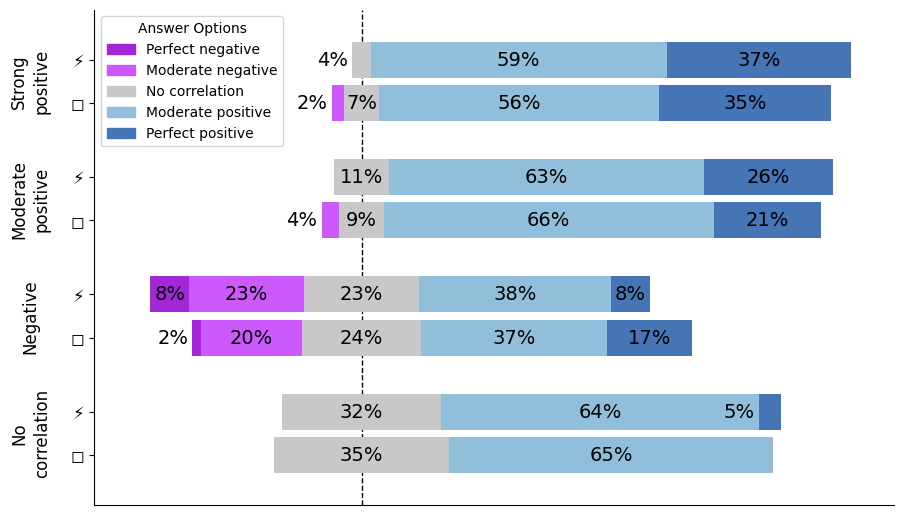

In [64]:
plot_scenario_likert_relevance("figures/likert_scenario_relevance.pdf")


In [ ]:
def plot_likert_simple(
    data,
    out_path,
    legend_title=None,
    legend_loc="center right",
    normalize=False,
    category_labels=None,
    category_colors=None,
    text_color="black",
    fontsize=9,
    percentages=True,
    x_axis_lables=None,
    plot_title="",
):
    import numpy as np
    import matplotlib.pyplot as plt

    groups = list(data.keys())
    cats = [1, 2, 3, 4, 5]

    raw_counts = np.array([[data[g][c] for c in cats] for g in groups], dtype=float)
    row_totals = raw_counts.sum(axis=1, keepdims=True)

    counts = raw_counts / row_totals * 100 if normalize else raw_counts.copy()
    c1, c2, c3, c4, c5 = counts.T

    left1 = -(c1 + c2) - c3 / 2
    left2 = -c2 - c3 / 2
    left3 = -c3 / 2
    left4 = c3 / 2
    left5 = c3 / 2 + c4

    lefts = [left1, left2, left3, left4, left5]
    widths = [c1, c2, c3, c4, c5]

    default_colors = {
        1: "#b2182b",
        2: "#ef8a62",
        3: "#f7f7f7",
        4: "#67a9cf",
        5: "#2166ac",
    }
    colors = default_colors if category_colors is None else {
        c: category_colors.get(c, default_colors[c]) for c in cats
    }

    bar_h = 0.90
    row_gap = 0.35
    y_pos = np.arange(len(groups)) * (1.0 + row_gap)

    fig_height = max(3.2, 0.8 + 0.75 * len(groups))
    fig, ax = plt.subplots(figsize=(9.0, fig_height))

    ax.axvline(0, color="black", linewidth=1, linestyle="--", zorder=0)

    value_fontsize = max(fontsize, 12) + 2

    # For tiny segments, push label just left of the segment
    min_width_for_inside = 6.5 if normalize else 3.5  # <- 4% goes outside now (when normalize=True)
    label_pad = 0.9 if normalize else 0.6

    for idx, cat in enumerate(cats):
        for row in range(len(groups)):
            w = float(widths[idx][row])
            if w <= 0:
                continue

            x_left = float(lefts[idx][row])
            y = float(y_pos[row])

            ax.barh(
                y,
                w,
                left=x_left,
                height=bar_h,
                color=colors[cat],
                edgecolor="none",
                linewidth=0,
                zorder=10,
            )

            pct = raw_counts[row, idx] / row_totals[row, 0] * 100
            if pct <= 0:
                continue
            label = f"{pct:.0f}%"

            if w < min_width_for_inside:
                ax.text(
                    x_left - label_pad,
                    y,
                    label,
                    ha="right",
                    va="center",
                    fontsize=value_fontsize,
                    color=text_color,
                    zorder=20,
                )
            else:
                ax.text(
                    x_left + w / 2,
                    y,
                    label,
                    ha="center",
                    va="center",
                    fontsize=value_fontsize,
                    color=text_color,
                    zorder=20,
                )

    ax.set_yticks(y_pos)
    ax.set_yticklabels(groups, fontsize=fontsize)
    ax.set_title(plot_title)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_xticks([])
    ax.set_xticklabels([])
    ax.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)

    max_right = np.max(left5 + c5)
    max_left = np.min(left1)
    rng = (max_right - max_left) if (max_right > max_left) else 1.0
    left_pad = 0.16 * rng
    right_pad = 0.06 * rng
    ax.set_xlim(max_left - left_pad, max_right + right_pad)

    ax.set_ylim(y_pos.min() - (bar_h / 2 + 0.5), y_pos.max() + (bar_h / 2 + 0.5))

    if category_labels is None:
        category_labels = {i: str(i) for i in cats}

    handles, texts = [], []
    for i in cats:
        lab = category_labels.get(i, "")
        if lab:
            handles.append(plt.Rectangle((0, 0), 1, 1, color=colors[i]))
            texts.append(lab)

    ax.legend(handles, texts, loc=legend_loc, title=legend_title if legend_title else None)

    fig.subplots_adjust(left=0.22)
    plt.tight_layout()
    if out_path:
        plt.savefig(out_path, dpi=300)
    plt.show()


In [ ]:
def plot_scenario_likert(out_path):
    scenario_data = {
        "No correlation": {1: 0, 2: 0, 3: 26, 4: 49, 5: 1},
        "Negative": {1: 3, 2: 18, 3: 20, 4: 32, 5: 10},
        "Moderate positive": {1: 0, 2: 2, 3: 8, 4: 54, 5: 19},
        "Strong positive": {1: 0, 2: 2, 3: 6, 4: 47, 5: 29},
    }

    category_labels = {
        5: "Perfect positive",
        4: "Moderate positive",
        3: "No correlation",
        2: "Moderate negative",
        1: "Perfect negative"
    }

    my_colors = {
        1: "#a227d7",
        2: "#cb59fc",
        3: "#c9c7c7",
        4: "#91bfdb",
        5: "#4575b4"
    }

    plot_likert_simple(
        scenario_data,
        out_path=out_path,
        legend_title="Answer Options",
        legend_loc="upper left",
        normalize=False,
        category_labels=category_labels,
        category_colors=my_colors,
        fontsize=12,
        percentages=False,
        #plot_title="Responses to 'How important is the energy consumption of your software product for ...'"
    )

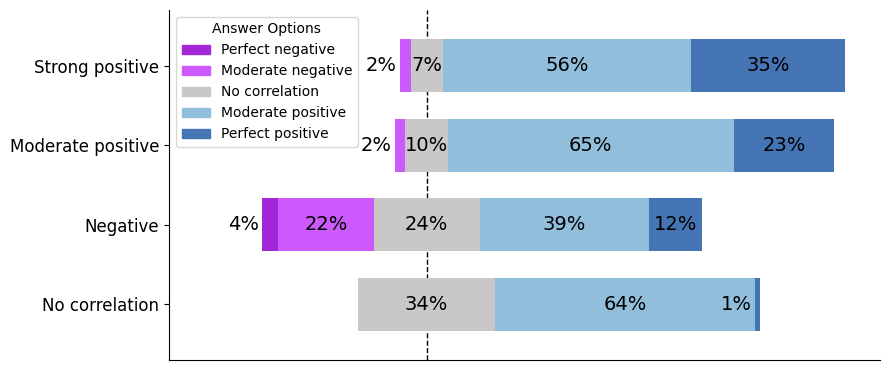

In [ ]:
plot_scenario_likert("figures/likert_scenario.pdf")

In [67]:
def plot_proxy_suitability_likert(out_path):
    proxy_data = {
        "Network utilization": {1: 9,  2: 22, 3: 0,  4: 27, 5: 12},
        "Cloud provider cost": {1: 8,  2: 15, 3: 0,  4: 22, 5: 8},
        "RAM utilization":     {1: 15, 2: 18, 3: 0,  4: 33, 5: 11},
        "Disc utilization":    {1: 6,  2: 20, 3: 0,  4: 36, 5: 11},
        "Electricity bills":   {1: 11, 2: 8,  3: 0,  4: 20, 5: 21},
        "Runtime performance": {1: 2,  2: 6,  3: 0,  4: 40, 5: 27},
        "CPU utilization":     {1: 0,  2: 6,  3: 0,  4: 29, 5: 44},
        "Battery utilization": {1: 1,  2: 3,  3: 0,  4: 14, 5: 45},
    }

    category_labels = {
        5: "Highly suitable",
        4: "Somewhat suitable",
        3: "",
        2: "Somewhat unsuitable",
        1: "Completely unsuitable",
    }

    my_colors = {
        1: "#a227d7",
        2: "#cb59fc",
        3: "#c9c7c7",
        4: "#91bfdb",
        5: "#4575b4"
    }

    plot_likert_simple(
        proxy_data,
        out_path=out_path,
        legend_loc="center left",
        normalize=False,
        category_labels=category_labels,
        category_colors=my_colors,
        fontsize=12,
        percentages=False,
        x_axis_lables=['Unsuitable','','Suitable'],
        #plot_title="Responses to 'How important is the energy consumption of your software product for ...'"
    )

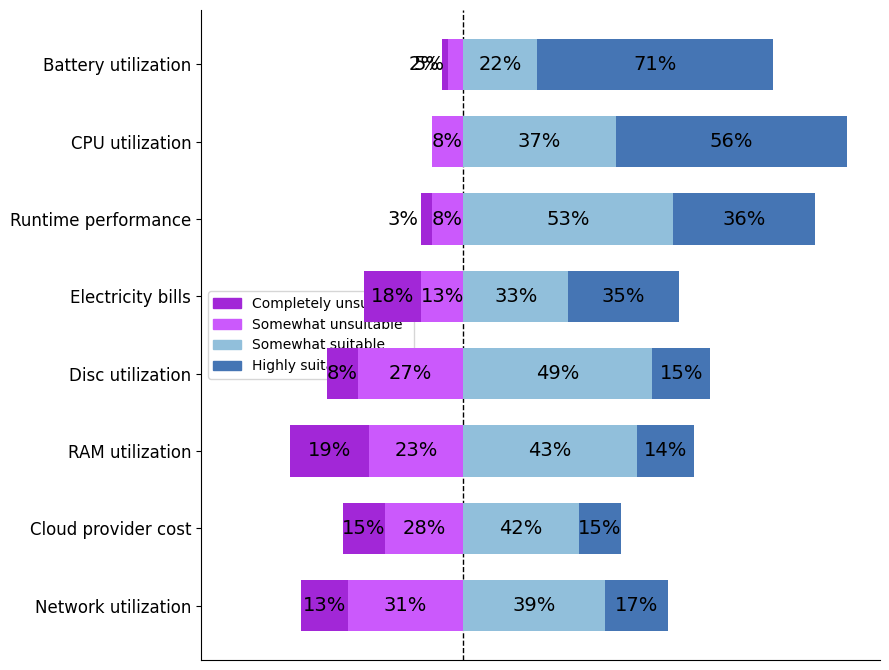

In [68]:
plot_proxy_suitability_likert("figures/likert_suitability.pdf")